In [1]:
%pip install numpy pandas librosa torch torchaudio matplotlib seaborn tqdm ipywidgets scikit-learn optuna --quiet

Note: you may need to restart the kernel to use updated packages.


%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [54]:
import os
import numpy as np
import pandas as pd
import librosa
import torchaudio
import warnings
import logging
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [55]:
os.environ["DATASET_DIR"] = "/datasets/kaspoas"


In [89]:
BATCH_SIZE = 64 #baseline 64
LR = 5e-4 #baseline 1e-3
MAX_EPOCHS = 100
PATIENCE = 7 #stops after 5 epcohs with no improvement
MIN_DELTA = 1e-3 #min improvement required
SPEC_AUG = True
RAND_CROP = True
CROP_FRAMES = 256

CNN_MIN_FILTER = 32 #baseline 16 - keep 32(better acc)
LSTM_HIDDEN = 128 #baseline 128
LSTM_LAYERS = 2 #baseline 2
DROPOUT = 0.1 #baseline 0.3
WEIGHT_DECAY = 1e-5

RUN_NAME = "spec_aug"

In [90]:
# Pick which cleaned FMA subset to train on. 
SUBSET = "small"  # or "medium"
if SUBSET not in {"small", "medium"}:
    raise ValueError("SUBSET must be either 'small' or 'medium'.")

# Resolve paths from either the project root or the code/ subdirectory.
PROJECT_CANDIDATES = [Path.cwd(), Path.cwd().parent]

if "DATASET_DIR" in os.environ:
    PROJECT_CANDIDATES.append(Path(os.environ["DATASET_DIR"]))
    
for candidate in PROJECT_CANDIDATES:
    preprocessed_path = candidate / "fma_preprocessed"
    if preprocessed_path.exists():
        PROJECT_DIR = candidate.resolve()
        PREPROCESSED_DIR = preprocessed_path.resolve()
        break
else:
    raise FileNotFoundError("Could not find fma_metadata/features.csv and fma_preprocessed/.")

# Files written by data_preprocessing.ipynb.
TRAIN_SPEC_PATH = PREPROCESSED_DIR / "spectrograms_manifest_training.csv"
VAL_SPEC_PATH   = PREPROCESSED_DIR / "spectrograms_manifest_validation.csv"
TEST_SPEC_PATH  = PREPROCESSED_DIR / "spectrograms_manifest_test.csv"
GENRE_MAP_PATH = PREPROCESSED_DIR / f"genre_to_idx_{SUBSET}.csv"

print({
    "SUBSET": SUBSET,
    "PROJECT_DIR": str(PROJECT_DIR),
    "PREPROCESSED_DIR": str(PREPROCESSED_DIR),
    "GENRE_MAP_PATH": str(GENRE_MAP_PATH),
    "TRAIN_SPEC_PATH": str(TRAIN_SPEC_PATH),
})



{'SUBSET': 'small', 'PROJECT_DIR': '/datasets/kaspoas', 'PREPROCESSED_DIR': '/datasets/kaspoas/fma_preprocessed', 'GENRE_MAP_PATH': '/datasets/kaspoas/fma_preprocessed/genre_to_idx_small.csv', 'TRAIN_SPEC_PATH': '/datasets/kaspoas/fma_preprocessed/spectrograms_manifest_training.csv'}


In [91]:
# Data loading from data_preprocessing.ipynb spectrogram outputs

def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}.\nRun data_preprocessing.ipynb first.")

    df = pd.read_csv(path)
    df = df.copy()
    df["track_id"] = df["track_id"].astype(int)
    df["label"] = df["label"].astype(int)

    # Convert saved paths into Path objects
    df["spectrogram_path"] = df["spectrogram_path"].apply(Path)

    return df


class SpecDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, augment=False, random_crop=False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment
        self.crop = random_crop

    def __len__(self):
        return len(self.frame)

    def spec_augment(self, spec):
        # spec shape: (1, n_mels, time)
        _, n_mels, n_frames = spec.shape

        # Light frequency mask
        f = np.random.randint(0, 5)
        if f > 0:
            f0 = np.random.randint(0, max(1, n_mels - f))
            spec[:, f0:f0 + f, :] = 0

        # Light time mask
        t = np.random.randint(0, 40)
        if t > 0:
            t0 = np.random.randint(0, max(1, n_frames - t))
            spec[:, :, t0:t0 + t] = 0

        return spec
        
    def random_crop(self, spec):
        if self.crop:
            # random crop for training
            if spec.shape[2] > CROP_FRAMES:
                start = np.random.randint(0, spec.shape[2] - CROP_FRAMES)
        else:
            # deterministic crop for val/test
            T = spec.shape[2]
            if T <= CROP_FRAMES:
                return spec
            start = (T - CROP_FRAMES) // 2
        return spec[:, :, start:start + CROP_FRAMES]

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        spec = np.load(row["spectrogram_path"]).astype(np.float32)

        # Ensure shape is (channels, n_mels, time)
        if spec.ndim == 2:
            spec = spec[None, :, :]

        spec = self.random_crop(spec)

        if self.augment:
            spec = self.spec_augment(spec)

        label = int(row["label"])
        track_id = int(row["track_id"])  # already in your dataframe
        
        return torch.from_numpy(spec), torch.tensor(label, dtype=torch.long), track_id


## Load Data

In [92]:

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Using device: {device}  ({n_gpus} GPU(s))")

# load preprocessed spectrograms
print("Loading preprocessed FMA spectrograms...")

train_df = load_data(TRAIN_SPEC_PATH)
val_df   = load_data(VAL_SPEC_PATH)
test_df  = load_data(TEST_SPEC_PATH)

class_names = (train_df[["label", "genre"]].drop_duplicates().sort_values("label")["genre"].tolist())

NUM_CLASSES = len(class_names)

print(f"Classes found: {NUM_CLASSES} -> {class_names}")
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")


# get spectrogram dimensions from one file
sample_spec = np.load(train_df.iloc[0]["spectrogram_path"])

if sample_spec.ndim == 2:
    N_MELS, MAX_FRAMES = sample_spec.shape
elif sample_spec.ndim == 3:
    N_MELS, MAX_FRAMES = sample_spec.shape[-2], sample_spec.shape[-1]
else:
    raise ValueError(f"Expected 2D or 3D spectrogram, got shape {sample_spec.shape}")
    
print(f"Spectrogram shape: n_mels={N_MELS}, frames={MAX_FRAMES}")


# data loaders
num_workers = min(4 * max(n_gpus, 1), 4)
pin         = device.type == "cuda"

train_loader = DataLoader(SpecDataset(train_df, augment=SPEC_AUG, random_crop=RAND_CROP), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=num_workers, pin_memory=pin,
                          persistent_workers=num_workers > 0)
val_loader   = DataLoader(SpecDataset(val_df),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=num_workers, pin_memory=pin,
                          persistent_workers=num_workers > 0)
test_loader  = DataLoader(SpecDataset(test_df),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=num_workers, pin_memory=pin,
                          persistent_workers=num_workers > 0)

Using device: cuda  (2 GPU(s))
Loading preprocessed FMA spectrograms...
Classes found: 8 -> ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
Train: 6394  Val: 800  Test: 800
Spectrogram shape: n_mels=64, frames=2001


### Model

In [93]:
class ConvBlock(nn.Module):
    #Conv2D -> BatchNorm -> ReLU -> MaxPool block
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
            nn.Dropout2d(DROPOUT),
        )

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):
    def __init__(self):
        super().__init__()

        c = CNN_MIN_FILTER
        self.cnn = nn.Sequential(
            ConvBlock(1,   c, pool=(2, 2)),
            ConvBlock(c,  c*2, pool=(2, 2)),
            ConvBlock(c*2, c*4, pool=(2, 2)),
            ConvBlock(c*4,  c*8, pool=(4, 1)), 

        )
        self.freq_pool = nn.AdaptiveAvgPool2d((1, None))  # collapse F → 1, keep T


        # get LSTM input size from actual CNN output
        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, MAX_FRAMES)
            out = self.freq_pool(self.cnn(dummy))
            _, C, F, T = out.shape
        self.lstm_in = C*F


        self.lstm = nn.LSTM(
            input_size=self.lstm_in,
            hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT if LSTM_LAYERS > 1 else 0.0,
        )

        '''
        self.rnn = nn.GRU(
            input_size=self.lstm_in,
            hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT if LSTM_LAYERS > 1 else 0.0,
        )
        '''

        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(LSTM_HIDDEN * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(64, NUM_CLASSES),
        )

    def forward(self, x):
        x = self.freq_pool(self.cnn(x)) # (B, C, 1, T)
        B, C, F, T = x.shape
        x = x.squeeze(2).permute(0, 2, 1)  # (B, T, C)
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        return self.classifier(x)
        #return self.classifier(x[:, -1, :])


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for specs, labels, _ in tqdm(loader, desc="  Train", leave=False, unit="batch"):
        specs, labels = specs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(specs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        preds       = outputs.detach().argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for specs, labels, _ in tqdm(loader, desc="  Eval ", leave=False, unit="batch"):
        specs, labels = specs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs    = model(specs)
        loss       = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

@torch.no_grad()
def evaluate_track_level(model, df, criterion, device, n_crops=10):
    model.eval()
    track_scores = {}
    track_labels = {}
    for _, row in df.iterrows():
        spec = np.load(row["spectrogram_path"]).astype(np.float32)
        if spec.ndim == 2:
            spec = spec[None, :, :]

        tid = int(row["track_id"])
        label = int(row["label"])

        # Run n_crops random crops through the model
        crops = []
        for _ in range(n_crops):
            if spec.shape[2] > CROP_FRAMES:
                start = np.random.randint(0, spec.shape[2] - CROP_FRAMES)
                crop = spec[:, :, start:start + CROP_FRAMES]
            else:
                crop = spec
            crops.append(crop)

        batch = torch.from_numpy(np.stack(crops)).to(device)  # (n_crops, 1, n_mels, T)
        logits = model(batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()  # (n_crops, num_classes)

        track_scores.setdefault(tid, np.zeros(NUM_CLASSES))
        track_scores[tid] += probs.sum(axis=0)
        track_labels[tid] = label

    y_pred = [np.argmax(track_scores[tid]) for tid in track_labels]
    y_true = [track_labels[tid] for tid in track_labels]

    acc = np.mean(np.array(y_pred) == np.array(y_true))
    return acc, y_pred, y_true


## Results Functions

In [94]:
def make_results_dir(run_name):
    results_dir = Path("results") / run_name
    results_dir.mkdir(parents=True, exist_ok=True)
    return results_dir


def save_results(run_name, history, test_loss, test_acc, track_acc, y_true, y_pred, class_names, best_model_path):
    results_dir = make_results_dir(run_name)
    history_df = pd.DataFrame(history)

    # Save per-epoch training history
    history_df.to_csv(results_dir / "training_history.csv", index=False)

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(results_dir / "accuracy_curve.png", dpi=300)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(results_dir / "loss_curve.png", dpi=300)
    plt.show()

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(results_dir / "classification_report.csv")

    # Confusion matrix image
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(results_dir / "confusion_matrix.png", dpi=300)
    plt.show()

    # Shared comparison file
    summary_row = {
        "run_name": run_name,
        "best_train_accuracy": history_df["train_acc"].max(),
        "best_validation_accuracy": history_df["val_acc"].max(),
        "test_accuracy": test_acc,
        "weighted_f1": report["weighted avg"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "test_loss": test_loss,
        "best_validation_loss": history_df["val_loss"].min(),
        "epochs_completed": len(history_df),
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "cnn_min_filter": CNN_MIN_FILTER,
        "lstm_hidden": LSTM_HIDDEN,
        "lstm_layers": LSTM_LAYERS,
        "dropout": DROPOUT,
        "crop_frames": CROP_FRAMES,
        "spec_aug": SPEC_AUG,
        "rand_crop": RAND_CROP,
        "spec_length": 20,
        "dataset": SUBSET, 
        "track_level_acc": track_acc
    }

    comparison_path = Path("results") / "comparison_summary.csv"

    pd.DataFrame([summary_row]).to_csv(
        comparison_path,
        mode="a" if comparison_path.exists() else "w",
        header=not comparison_path.exists(),
        index=False
    )

    print(f"Saved results to: {results_dir}")
    print(f"Updated comparison file: {comparison_path}")
    print(f"Best model saved at: {best_model_path}")

Run name: spec_aug
Saving results to: results/spec_aug
Using device: cuda  (2 GPU(s))

Model parameters: 1,196,296
DataParallel(
  (module): CRNN(
    (cnn): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
          (4): Dropout2d(p=0.1, inplace=False)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
          (4): Dropout2d(p=0.1, inplace=Fals

  Train:   0%|          | 0/100 [00:00<?, ?batch/s]

  Eval :   0%|          | 0/13 [00:00<?, ?batch/s]

Train:      loss=1.9442  acc=0.2326
Validation: loss=1.8084  acc=0.3088
  -> best model saved

Epoch 2/100


  Train:   0%|          | 0/100 [00:00<?, ?batch/s]

...

/tmp/ipykernel_603379/2335168957.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base.load_state_dict(torch.load(best_model_path, map_location=device))


  Eval :   0%|          | 0/13 [00:00<?, ?batch/s]


Test loss=1.5100  acc=0.4838


/tmp/ipykernel_603379/2335168957.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base.load_state_dict(torch.load(best_model_path, map_location=device))



     track-level acc=0.4688

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.67      0.58      0.62       100
 Experimental       0.36      0.33      0.34       100
         Folk       0.27      0.27      0.27       100
      Hip-Hop       0.59      0.88      0.71       100
 Instrumental       0.40      0.48      0.44       100
International       0.57      0.55      0.56       100
          Pop       0.38      0.31      0.34       100
         Rock       0.64      0.47      0.54       100

     accuracy                           0.48       800
    macro avg       0.48      0.48      0.48       800
 weighted avg       0.48      0.48      0.48       800



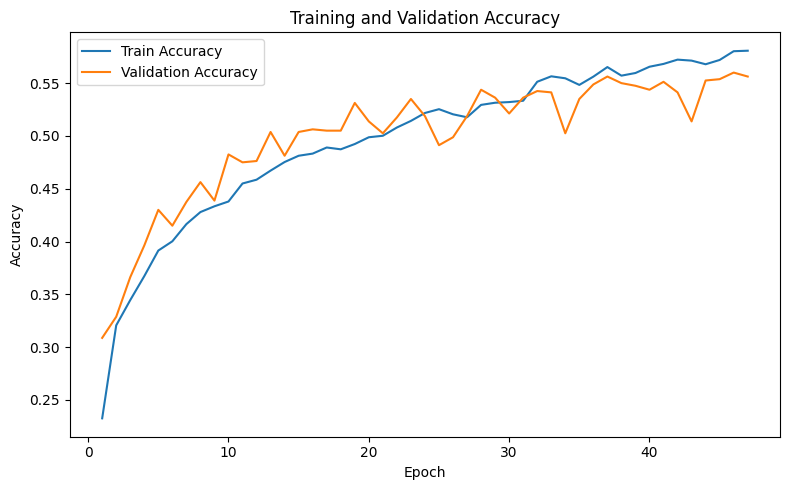

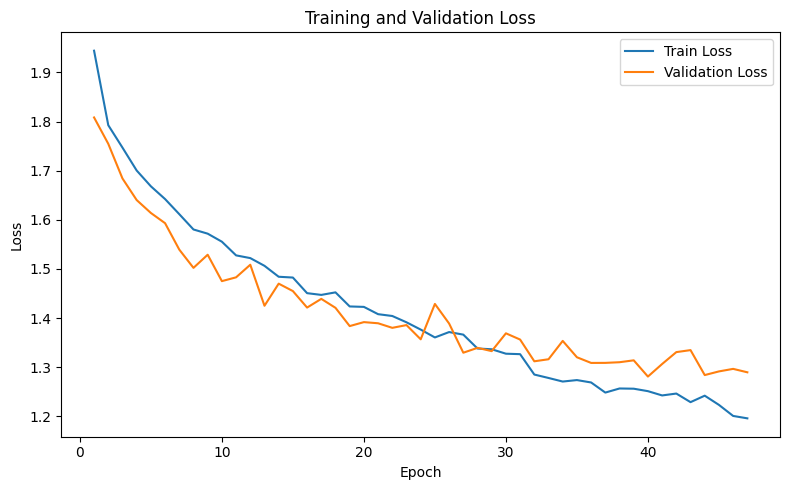

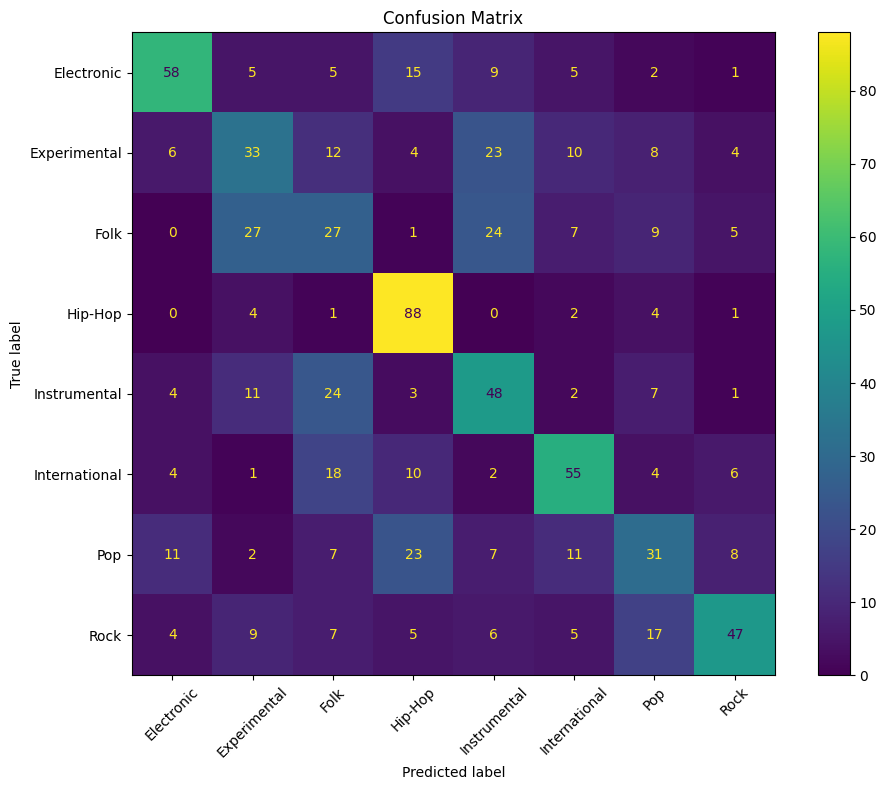

Saved results to: results/spec_aug
Updated comparison file: results/comparison_summary.csv
Best model saved at: results/spec_aug/best_crnn.pth


In [95]:
### Training


# results folder
results_dir = make_results_dir(RUN_NAME)
best_model_path = results_dir / "best_crnn.pth"

print(f"Run name: {RUN_NAME}")
print(f"Saving results to: {results_dir}")

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Using device: {device}  ({n_gpus} GPU(s))")


# model
model = CRNN()
if device.type == "cuda" and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

# training loop
best_acc = 0.0
best_loss = float("inf")
stagnant_epochs = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{MAX_EPOCHS}")
    train_loss, train_acc       = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc,  _, _  = evaluate(model, val_loader, criterion, device)

    print(f"Train:      loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"Validation: loss={val_loss:.4f}  acc={val_acc:.4f}")

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })
         
    
    if val_loss > best_loss + MIN_DELTA:
        stagnant_epochs += 1

    else:
        best_loss = val_loss
        stagnant_epochs = 0
        state = (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict())
        torch.save(state, best_model_path)
        print(f"  -> best model saved")

    scheduler.step(val_loss)

    if stagnant_epochs >= PATIENCE:
            print("Coverged on validation loss")
            break

# evaluation
base = model.module if isinstance(model, nn.DataParallel) else model
base.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc, test_preds, test_labels_out = evaluate(model, test_loader, criterion, device)
print(f"\nTest loss={test_loss:.4f}  acc={test_acc:.4f}")

# track-level eval
base = model.module if isinstance(model, nn.DataParallel) else model
base.load_state_dict(torch.load(best_model_path, map_location=device))

track_acc, track_preds, track_labels_out = evaluate_track_level(
    base, test_df, criterion, device, n_crops=10
)

print(f"\n     track-level acc={track_acc:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels_out, test_preds, target_names=class_names))


#save results
save_results(run_name=RUN_NAME, history=history, test_loss=test_loss, test_acc=test_acc, track_acc=track_acc, y_true=test_labels_out,
    y_pred=test_preds, class_names=class_names, best_model_path=best_model_path)



## Hyperparameter Tuning

In [71]:
N_TRIALS       = 30
TUNE_EPOCHS    = 20
TUNE_PATIENCE  = 3
TUNE_MIN_DELTA = 1e-3

def objective(trial):
    params = {
        "lr":             trial.suggest_categorical("lr", [5e-5, 1e-4, 5e-4, 1e-3, 5e-3]),
        "batch_size":     trial.suggest_categorical("batch_size", [32, 64, 128]),
        "cnn_min_filter": trial.suggest_categorical("cnn_min_filter", [16, 32, 64]),
        "lstm_hidden":    trial.suggest_categorical("lstm_hidden", [64, 128, 256]),
        "lstm_layers":    trial.suggest_categorical("lstm_layers", [1, 2, 3]),
        "dropout":        trial.suggest_categorical("dropout", [0.05, 0.1, 0.2, 0.3]),
        "weight_decay":   trial.suggest_categorical("weight_decay", [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]),
        "crop_frames":    trial.suggest_categorical("crop_frames", [256, 512, 768, 1024]),
    }

    # Patch all globals for this trial
    global CNN_MIN_FILTER, LSTM_HIDDEN, LSTM_LAYERS, DROPOUT, CROP_FRAMES
    CNN_MIN_FILTER = params["cnn_min_filter"]
    LSTM_HIDDEN    = params["lstm_hidden"]
    LSTM_LAYERS    = params["lstm_layers"]
    DROPOUT        = params["dropout"]
    CROP_FRAMES    = params["crop_frames"]

    train_loader_t = DataLoader(
        SpecDataset(train_df, augment=True, random_crop=True),
        batch_size=params["batch_size"], shuffle=True,
        num_workers=0, pin_memory=pin
    )
    val_loader_t = DataLoader(
        SpecDataset(val_df),
        batch_size=params["batch_size"], shuffle=False,
        num_workers=0, pin_memory=pin
    )

    try: 
        model     = CRNN().to(device)  # reads the patched globals as normal
        optimizer = optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6)
        
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(train_df["label"]),
            y=train_df["label"].values,
        )
        class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
        best_val_loss, stagnant = float("inf"), 0
    
        for epoch in range(1, TUNE_EPOCHS + 1):
            train_one_epoch(model, train_loader_t, optimizer, criterion, device)
            val_loss, _, _, _ = evaluate(model, val_loader_t, criterion, device)
            scheduler.step(val_loss)
    
            if val_loss < best_val_loss - TUNE_MIN_DELTA:
                best_val_loss, stagnant = val_loss, 0
            else:
                stagnant += 1
    
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
    
            if stagnant >= TUNE_PATIENCE:
                break

        return best_val_loss
        
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        raise optuna.exceptions.TrialPruned()

    finally:
        torch.cuda.empty_cache()

study = optuna.create_study(
    storage="sqlite:///crnn_study.db",
    study_name="crnn_fma_20s",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=5),
    load_if_exists=True,
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)



  0%|          | 0/30 [00:00<?, ?it/s]

C=128, T=250
CNN output shape: torch.Size([1, 128, 2, 128])


  Train:   0%|          | 0/200 [00:00<?, ?batch/s]

  Eval :   0%|          | 0/25 [00:00<?, ?batch/s]

  Train:   0%|          | 0/200 [00:00<?, ?batch/s]

...

  Train:   0%|          | 0/100 [00:00<?, ?batch/s]

  Eval :   0%|          | 0/13 [00:00<?, ?batch/s]

  Train:   0%|          | 0/100 [00:00<?, ?batch/s]

[W 2026-05-23 08:06:34,201] Trial 1 failed with parameters: {'lr': 0.0007309539835912913, 'batch_size': 64, 'cnn_min_filter': 64, 'lstm_hidden': 64, 'lstm_layers': 2, 'dropout': 0.1185801650879991, 'weight_decay': 0.000164092867306479, 'crop_frames': 768} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home-mscluster/kaspoas/miniconda3/envs/acml/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_603379/2446916585.py", line 53, in objective
    train_one_epoch(model, train_loader_t, optimizer, criterion, device)
  File "/tmp/ipykernel_603379/3037947411.py", line 94, in train_one_epoch
    total_loss += loss.item() * labels.size(0)
KeyboardInterrupt
[W 2026-05-23 08:06:34,204] Trial 1 failed with value None.


KeyboardInterrupt: 

In [12]:
print(f"Completed trials : {len(study.trials)}")
print(f"Pruned trials    : {sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials)}")
print(f"\nBest val loss    : {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")
    
# save hyperparameter results
hp_path = Path("results") / "tuning_results.csv"

hp_row = {"run_name": RUN_NAME, "best_val_loss": study.best_value, **study.best_params}

pd.DataFrame([hp_row]).to_csv(
    hp_path,
    mode="a" if hp_path.exists() else "w",
    header=not hp_path.exists(),
    index=False,
)

print(f"Saved hyperparameters to: {hp_path}")


Completed trials : 60
Pruned trials    : 23

Best val loss    : 1.3468
Best params:
  lr                  : 0.0015862331186763184
  batch_size          : 128
  cnn_min_filter      : 32
  lstm_hidden         : 128
  lstm_layers         : 1
  dropout             : 0.12525050869235044
  weight_decay        : 2.255341444538164e-05
  crop_frames         : 512
Saved hyperparameters to: results/tuning_results.csv


In [13]:
best = study.best_params

CNN_MIN_FILTER = best["cnn_min_filter"]
LSTM_HIDDEN    = best["lstm_hidden"]
LSTM_LAYERS    = best["lstm_layers"]
DROPOUT        = best["dropout"]
CROP_FRAMES    = best["crop_frames"]
BATCH_SIZE     = best["batch_size"]
LR             = best["lr"]
RUN_NAME       = "crnn_tuned"